In [38]:
import random, time, numpy as np, torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(
    root='data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(
    root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)


In [39]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # STUDENT: define three trainable Linear layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.activation = nn.ReLU()

    def forward(self, x):
        # STUDENT: flatten, apply Layer 1 + activation,
        # Layer 2 + activation, then Layer 3 logits
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)
        return logits

model = FashionMLP().to(device)
print(model)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): ReLU()
)


Layer 1 uses 784 input features because each Fashion-MNIST image has dimensions of 28 × 28 pixels. Flattening the image converts it into a vector containing 28×28=784 pixel values.

ReLU introduces non-linearity into the hidden layers. Without an activation function, multiple Linear layers would behave like a single linear transformation. ReLU also helps neural networks learn complex patterns efficiently.

The Fashion-MNIST dataset contains 10 different classes. Each output neuron corresponds to one class.

The final layer returns raw class scores called logits. nn.CrossEntropyLoss() expects raw logits and internally applies the necessary mathematical operations for classification. Therefore, Softmax should not be placed inside the model before the loss function.

In [40]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear previous gradients
        logits = model(images)         # forward propagation
        loss = criterion(logits, labels)
        loss.backward()                # backpropagation
        optimizer.step()               # parameter update

        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


A Fashion-MNIST image has a size of 28 × 28 pixels. Since each pixel represents one numerical input value, flattening the image produces 28 × 28 = 784 input features. Therefore, the first Linear layer uses 784 input features and produces 128 hidden features.

The hidden layers use the ReLU activation function to introduce non-linearity into the model. This allows the neural network to learn more complex patterns and relationships from the image pixels. The first hidden layer transforms 784 features into 128 features, while the second hidden layer transforms 128 features into 64 features.

The final Linear layer has 10 outputs because the Fashion-MNIST dataset contains 10 different clothing classes. Each output corresponds to one class, such as T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, or Ankle boot.

The model returns raw logits instead of Softmax probabilities because nn.CrossEntropyLoss() expects raw logits as its input. Softmax should not be placed inside the model before the loss function. It may be applied after training when probabilities need to be displayed.

In [41]:
class FashionMLP(nn.Module):
    def __init__(self, hidden1=128, activation_name="relu"):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(784, hidden1)
        self.fc2 = nn.Linear(hidden1, 64)
        self.fc3 = nn.Linear(64, 10)

        if activation_name == "relu":
            self.activation = nn.ReLU()
        elif activation_name == "tanh":
            self.activation = nn.Tanh()

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)

        return logits



In [42]:
import random
import time
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [43]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [44]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

print("Training images:", len(train_data))
print("Testing images:", len(test_data))

Training images: 60000
Testing images: 10000


In [45]:
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=256,
    shuffle=False
)

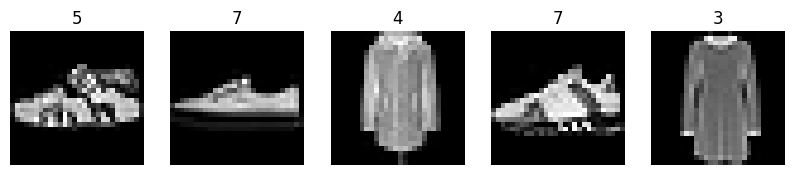

In [46]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1,5, figsize=(10,3))

for i in range(5):
    axes[i].imshow(images[i][0], cmap="gray")
    axes[i].set_title(labels[i].item())
    axes[i].axis("off")

plt.show()

In [47]:
class FashionMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        self.activation = nn.Tanh()

    def forward(self, x):

        x = self.flatten(x)

        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))

        x = self.fc3(x)

        return x

In [48]:
model = FashionMLP().to(device)

print(model)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): Tanh()
)


In [49]:
total_params = sum(p.numel() for p in model.parameters())

print("Total Parameters:", total_params)

images, labels = next(iter(train_loader))

print("Input:", images.shape)

x = model.flatten(images)
print("After Flatten:", x.shape)

x = model.activation(model.fc1(x))
print("After Layer 1:", x.shape)

x = model.activation(model.fc2(x))
print("After Layer 2:", x.shape)

x = model.fc3(x)
print("After Layer 3:", x.shape)

Total Parameters: 109386
Input: torch.Size([64, 1, 28, 28])
After Flatten: torch.Size([64, 784])
After Layer 1: torch.Size([64, 128])
After Layer 2: torch.Size([64, 64])
After Layer 3: torch.Size([64, 10])


In [50]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [51]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        correct += (outputs.argmax(1) == labels).sum().item()

        total += labels.size(0)

    return running_loss / total, correct / total

In [52]:
def evaluate(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    predictions = []
    true_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)

            pred = outputs.argmax(1)

            correct += (pred == labels).sum().item()

            total += labels.size(0)

            predictions.extend(pred.cpu().numpy())

            true_labels.extend(labels.cpu().numpy())

    return (
        running_loss / total,
        correct / total,
        predictions,
        true_labels
    )

In [80]:
# Create the base model
model = FashionMLP(
    hidden1=128,
    activation_name="relu"
).to(device)

# Print model architecture
print("MODEL ARCHITECTURE")
print(model)

# Count trainable parameters only
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nExact Trainable Parameter Count:")
print(trainable_params)

MODEL ARCHITECTURE
FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): ReLU()
)

Exact Trainable Parameter Count:
109386


In [66]:
test_loss, test_accuracy, predictions, true_labels

(0.36234025349617005,
 0.8695,
 [np.int64(9),
  np.int64(2),
  np.int64(1),
  np.int64(1),
  np.int64(6),
  np.int64(1),
  np.int64(4),
  np.int64(6),
  np.int64(5),
  np.int64(7),
  np.int64(4),
  np.int64(5),
  np.int64(7),
  np.int64(3),
  np.int64(4),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(8),
  np.int64(0),
  np.int64(2),
  np.int64(7),
  np.int64(7),
  np.int64(5),
  np.int64(1),
  np.int64(2),
  np.int64(6),
  np.int64(0),
  np.int64(9),
  np.int64(3),
  np.int64(8),
  np.int64(8),
  np.int64(3),
  np.int64(3),
  np.int64(8),
  np.int64(0),
  np.int64(7),
  np.int64(5),
  np.int64(7),
  np.int64(9),
  np.int64(0),
  np.int64(1),
  np.int64(6),
  np.int64(7),
  np.int64(6),
  np.int64(9),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(4),
  np.int64(6),
  np.int64(5),
  np.int64(8),
  np.int64(2),
  np.int64(2),
  np.int64(8),
  np.int64(4),
  np.int64(8),
  np.int64(0),
  np.int64(7),
  np.int64(7),
  np.int64(8),
  np.int64(5),
  np.int6

In [67]:
from sklearn.metrics import f1_score

def run_experiment(
    run_name,
    hidden1,
    activation_name,
    optimizer_name,
    learning_rate,
    epochs=10
):

    print("\n" + "="*50)
    print(f"RUN {run_name}")
    print("="*50)

    # Reset seed for reproducibility
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    # Create model
    model = FashionMLP(
        hidden1=hidden1,
        activation_name=activation_name
    ).to(device)

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Select optimizer
    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    # Count parameters
    total_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print("Trainable Parameters:", total_params)

    # Store history
    train_losses = []
    train_accuracies = []

    # Start training timer
    start_train = time.time()

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * labels.size(0)

            predictions = outputs.argmax(1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        train_loss = running_loss / total
        train_accuracy = correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Accuracy: {train_accuracy:.4f}"
        )

    end_train = time.time()

    training_time = end_train - start_train

    # Evaluate model
    start_inference = time.time()

    test_loss, test_accuracy, predictions, true_labels = evaluate(
        model,
        test_loader
    )

    end_inference = time.time()

    inference_time = end_inference - start_inference

    # Calculate Macro F1
    macro_f1 = f1_score(
        true_labels,
        predictions,
        average="macro"
    )

    print("\nFinal Results:")
    print("Train Loss:", train_losses[-1])
    print("Test Loss:", test_loss)
    print("Test Accuracy:", test_accuracy)
    print("Macro F1:", macro_f1)
    print("Training Time:", training_time, "seconds")
    print("Inference Time:", inference_time, "seconds")

    return {
        "Run": run_name,
        "Parameters": total_params,
        "Train Loss": train_losses[-1],
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy,
        "Macro F1": macro_f1,
        "Training Time": training_time,
        "Inference Time": inference_time,
        "Train Losses": train_losses,
        "Train Accuracies": train_accuracies
    }

In [75]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies_history = [] # Renaming to avoid conflict if test_accuracies is used elsewhere

start_train = time.time()

for epoch in range(10):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    # Evaluate on the test set at the end of each epoch
    epoch_test_loss, epoch_test_acc, _, _ = evaluate(
        model,
        test_loader
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(epoch_test_loss)
    test_accuracies_history.append(epoch_test_acc)

    print(
        f"Epoch {epoch+1}/10 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {epoch_test_loss:.4f} | "
        f"Test Acc: {epoch_test_acc:.4f}"
    )

end_train = time.time()

train_time = end_train - start_train

print("\nTraining Time:", train_time, "seconds")


Epoch 1/10 | Train Loss: 0.5126 | Train Acc: 0.8200 | Test Loss: 0.4322 | Test Acc: 0.8396
Epoch 2/10 | Train Loss: 0.3775 | Train Acc: 0.8631 | Test Loss: 0.4002 | Test Acc: 0.8524
Epoch 3/10 | Train Loss: 0.3451 | Train Acc: 0.8741 | Test Loss: 0.3924 | Test Acc: 0.8577
Epoch 4/10 | Train Loss: 0.3214 | Train Acc: 0.8827 | Test Loss: 0.3844 | Test Acc: 0.8610
Epoch 5/10 | Train Loss: 0.3070 | Train Acc: 0.8871 | Test Loss: 0.3584 | Test Acc: 0.8720
Epoch 6/10 | Train Loss: 0.2954 | Train Acc: 0.8915 | Test Loss: 0.3676 | Test Acc: 0.8677
Epoch 7/10 | Train Loss: 0.2835 | Train Acc: 0.8961 | Test Loss: 0.3540 | Test Acc: 0.8718
Epoch 8/10 | Train Loss: 0.2732 | Train Acc: 0.8987 | Test Loss: 0.3541 | Test Acc: 0.8740
Epoch 9/10 | Train Loss: 0.2631 | Train Acc: 0.9030 | Test Loss: 0.3823 | Test Acc: 0.8642
Epoch 10/10 | Train Loss: 0.2568 | Train Acc: 0.9043 | Test Loss: 0.3537 | Test Acc: 0.8728

Training Time: 138.83959698677063 seconds


In [54]:
test_loss, test_accuracy, predictions, true_labels = evaluate(
    model,
    test_loader
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.36234025349617005
Test Accuracy: 0.8695


In [55]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(
    true_labels,
    predictions,
    average="macro"
)

print("Macro F1:", macro_f1)

Macro F1: 0.868664255457954


In [56]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(
    true_labels,
    predictions,
    average="macro"
)

print("Macro F1:", macro_f1)

Macro F1: 0.868664255457954


In [57]:
start = time.time()

test_loss, test_accuracy, predictions, true_labels = evaluate(
    model,
    test_loader
)

end = time.time()

inference_time = end - start

print("Inference Time:", inference_time, "seconds")

Inference Time: 1.5695974826812744 seconds


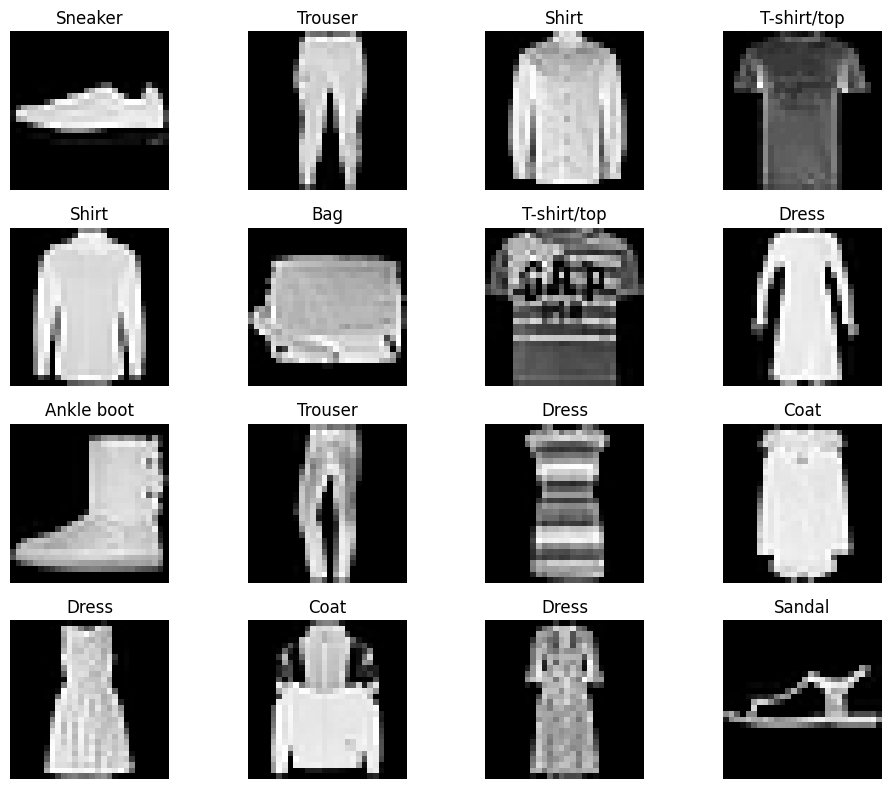

In [58]:
# Required Output 1 — Fashion-MNIST Samples with Correct Class Labels

import matplotlib.pyplot as plt

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 8))

for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [59]:
# Required Output 2 — Input and Intermediate Tensor Shapes

batch_images, batch_labels = next(iter(train_loader))

print("Input batch shape:", batch_images.shape)

x = batch_images.to(device)

# Flatten layer
x = x.view(x.size(0), -1)

print("After Flatten:", x.shape)

# First Linear Layer
x = model.fc1(x)

print("After First Linear Layer:", x.shape)

# Activation
x = model.activation(x)

# Second Linear
x = model.fc2(x)

print("After Second Linear Layer:", x.shape)

# Activation
x = model.activation(x)

# Output Layer
x = model.fc3(x)

print("Output shape:", x.shape)


Input batch shape: torch.Size([64, 1, 28, 28])
After Flatten: torch.Size([64, 784])
After First Linear Layer: torch.Size([64, 128])
After Second Linear Layer: torch.Size([64, 64])
Output shape: torch.Size([64, 10])


In [61]:
class FashionMLP(nn.Module):
    def __init__(self, hidden1=128, activation_name="relu"):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(784, hidden1)
        self.fc2 = nn.Linear(hidden1, 64)
        self.fc3 = nn.Linear(64, 10)

        if activation_name == "relu":
            self.activation = nn.ReLU()
        elif activation_name == "tanh":
            self.activation = nn.Tanh()

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)

        return logits

In [68]:
results = []

# RUN A: SGD
results.append(
    run_experiment(
        run_name="A",
        hidden1=128,
        activation_name="relu",
        optimizer_name="SGD",
        learning_rate=0.01,
        epochs=10
    )
)

# RUN B: Adam
results.append(
    run_experiment(
        run_name="B",
        hidden1=128,
        activation_name="relu",
        optimizer_name="Adam",
        learning_rate=0.001,
        epochs=10
    )
)

# RUN C: Wider Layer 1
results.append(
    run_experiment(
        run_name="C",
        hidden1=256,
        activation_name="relu",
        optimizer_name="Adam",
        learning_rate=0.001,
        epochs=10
    )
)

# RUN D: Tanh
results.append(
    run_experiment(
        run_name="D",
        hidden1=128,
        activation_name="tanh",
        optimizer_name="Adam",
        learning_rate=0.001,
        epochs=10
    )
)


RUN A
Trainable Parameters: 109386
Epoch 1/10 | Loss: 1.0104 | Accuracy: 0.6736
Epoch 2/10 | Loss: 0.5534 | Accuracy: 0.8024
Epoch 3/10 | Loss: 0.4873 | Accuracy: 0.8279
Epoch 4/10 | Loss: 0.4533 | Accuracy: 0.8384
Epoch 5/10 | Loss: 0.4301 | Accuracy: 0.8474
Epoch 6/10 | Loss: 0.4121 | Accuracy: 0.8531
Epoch 7/10 | Loss: 0.3980 | Accuracy: 0.8579
Epoch 8/10 | Loss: 0.3868 | Accuracy: 0.8625
Epoch 9/10 | Loss: 0.3765 | Accuracy: 0.8656
Epoch 10/10 | Loss: 0.3663 | Accuracy: 0.8683

Final Results:
Train Loss: 0.36628259936173757
Test Loss: 0.40337292821407317
Test Accuracy: 0.8564
Macro F1: 0.855538696492523
Training Time: 116.90632104873657 seconds
Inference Time: 1.7842020988464355 seconds

RUN B
Trainable Parameters: 109386
Epoch 1/10 | Loss: 0.5124 | Accuracy: 0.8141
Epoch 2/10 | Loss: 0.3783 | Accuracy: 0.8608
Epoch 3/10 | Loss: 0.3406 | Accuracy: 0.8747
Epoch 4/10 | Loss: 0.3160 | Accuracy: 0.8833
Epoch 5/10 | Loss: 0.2990 | Accuracy: 0.8881
Epoch 6/10 | Loss: 0.2800 | Accuracy: 

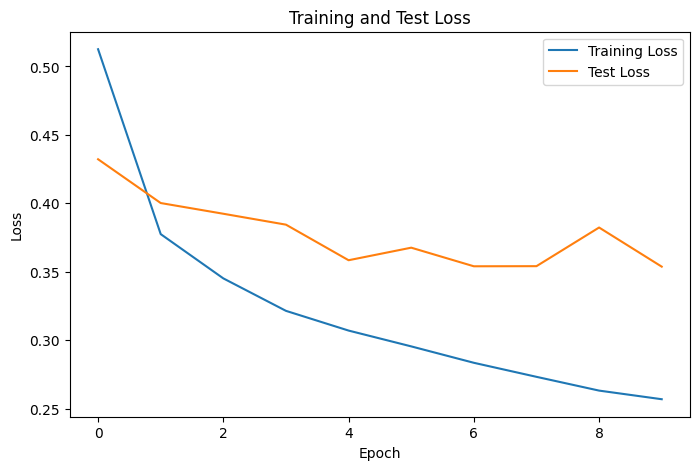

In [77]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")

plt.legend()
plt.show()


In [72]:
train_accuracies = []
test_accuracies = []

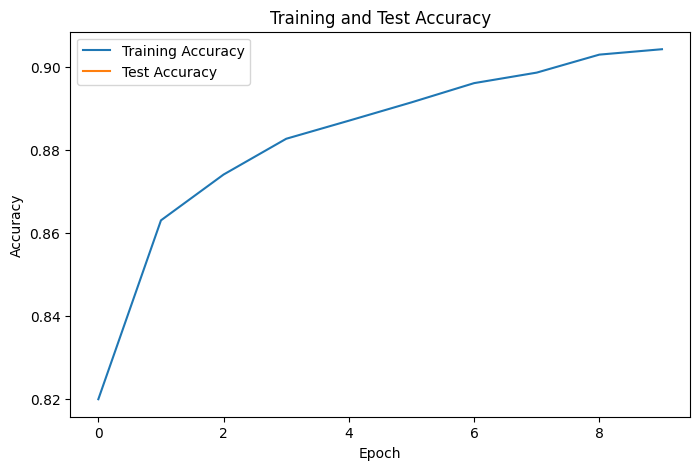

In [76]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")

plt.legend()
plt.show()

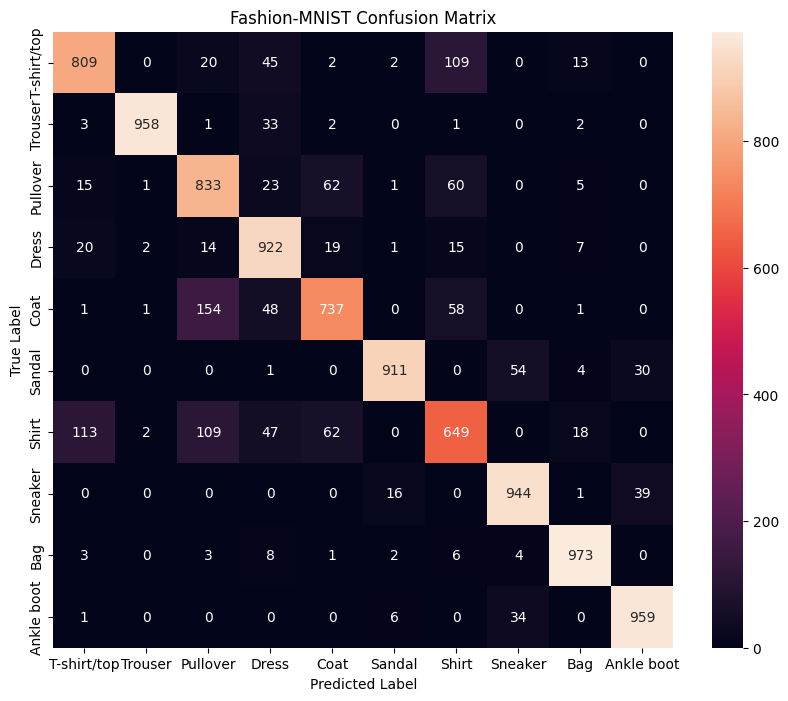

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    true_labels,
    predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fashion-MNIST Confusion Matrix")

plt.show()

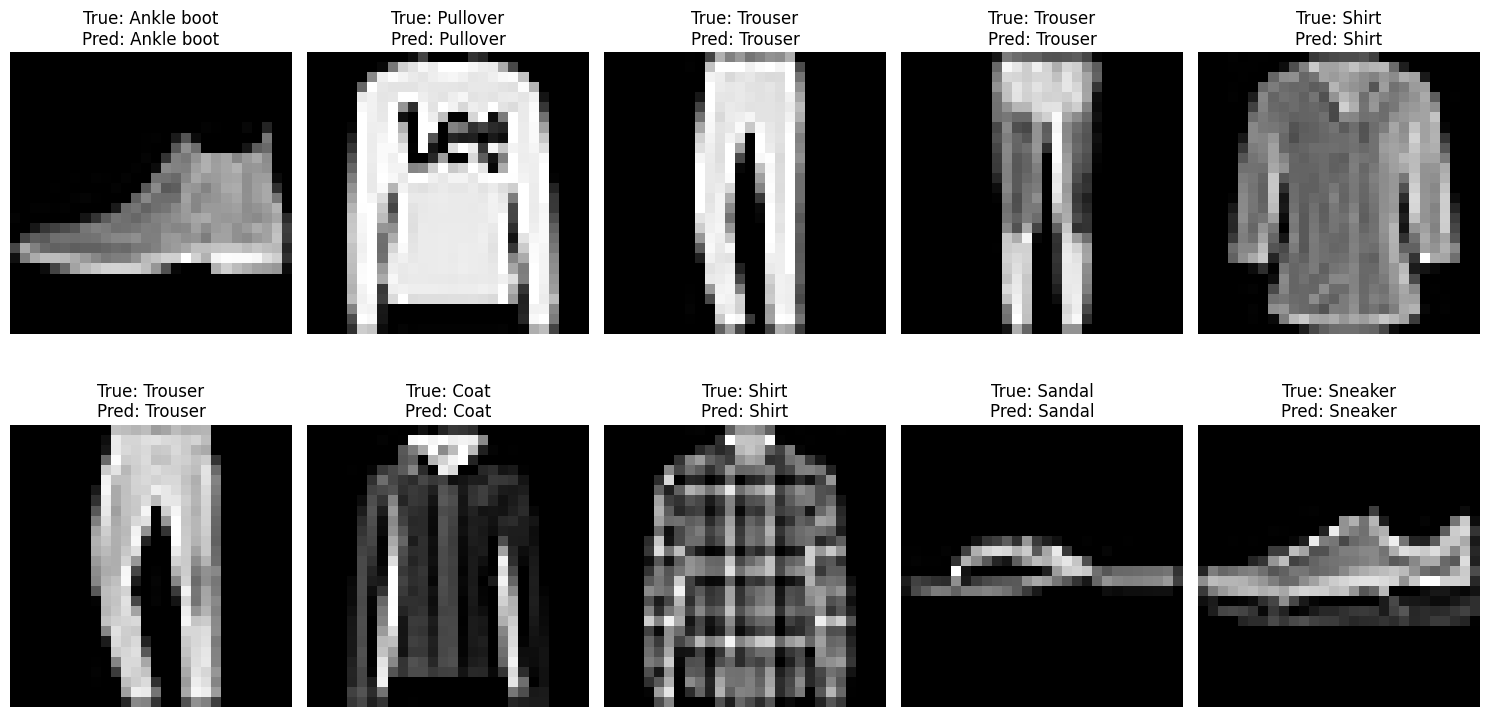

In [79]:
images, labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)

predictions = outputs.argmax(1)

plt.figure(figsize=(15, 8))

for i in range(10):

    plt.subplot(2, 5, i+1)

    image = images[i].cpu().squeeze()

    true_label = class_names[labels[i].item()]
    predicted_label = class_names[predictions[i].item()]

    plt.imshow(image, cmap="gray")

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [69]:
import pandas as pd

comparison_table = pd.DataFrame(results)

comparison_table = comparison_table[
    [
        "Run",
        "Parameters",
        "Train Loss",
        "Test Loss",
        "Test Accuracy",
        "Macro F1",
        "Training Time",
        "Inference Time"
    ]
]

comparison_table

,Run,Parameters,Train Loss,Test Loss,Test Accuracy,Macro F1,Training Time,Inference Time
0,A,109386,0.366283,0.403373,0.8564,0.855539,116.906321,1.784202
1,B,109386,0.236670,0.342562,0.8833,0.883320,117.362259,1.561694
2,C,218058,0.225827,0.353576,0.8799,0.880962,125.800750,1.593117
3,D,109386,0.258538,0.345414,0.8798,0.880376,117.994207,1.900905
